## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

## |  Trabajo Semanal N°2




&emsp;&emsp;&emsp; En este trabajo semanal se busca construir una senoidal contaminada por un nivel de ruido a una frecuencia $f_0$ determinada y cuya energía esté normalizada, con la cual simularemos el bloque de cuatización de un ADC de 
**$n$ Bits** para analizar cómo se comporta temporalmente la señal, y cómo se comporta su espectro de frecuencias. En esta experiencia se verá el comportamiento de la señal cuantizada en el domino temporal, el frecuencial, y veremos qué distribución tiene su ruido de cuantización.

&emsp;&emsp;&emsp; Definimos la senoidal mediante los siguentes parámetros:
- La frecuencia $f_0$ (Hz)
- La potencia media de la señal (Watts)
- La cantidad de muestras digitalizada por el ADC (# muestras)
  
Los demás parámetros se mantendrán constantes con respecto a los trabajos anteriores.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def cuantizar(x,vref,q):
    niveles = 2 ** B
    delta = q
    v_min, v_max = -vref, vref
    #El último nível válido lo defino como Vref - q porque sino satura de manera extraña
    x_sat = np.clip(x, v_min, v_max - delta)
    # Índice del nivel y reconstrucción de la muestra cuantizada.
    indices = np.around((x_sat - v_min) / delta)
    indices = np.clip(indices, 0, niveles - 1)
    x_q = v_min + indices * delta

    error_q = x_q - x
    return x_q, error_q

#Factores para armar la Senoidal
N=1000
Ps = 1
ph = 0
dc=0
fs = 1000
ff= fs/N #Podemos verlo como la resolución espectral
nn = np.arange(N)
k=1
vmax =np.sqrt(2*Ps*ff)
#Factores para cuantizar la señal
B = 4
vref = 2
q =(2*vref)/(2**B)
#Factores para parametrizar el ruido
kn = 1
pr = kn*((q**2)/12)

&emsp;&emsp;&emsp; Definidos los parámetros para la formación de la senoidal, su ruido y los parámetros para su cuantización pasamos a formar primeramente la senoidal ruidosa.  



#### ->  Formación de la senoidal ruidosa
&emsp;&emsp;&emsp; Antes de cuantizar la señal deseada, debemos formarla. Solo la representaremos en su dominio temporal ya que en la tarea 
anterior de desarrolló a profundidad este tipo de señales.

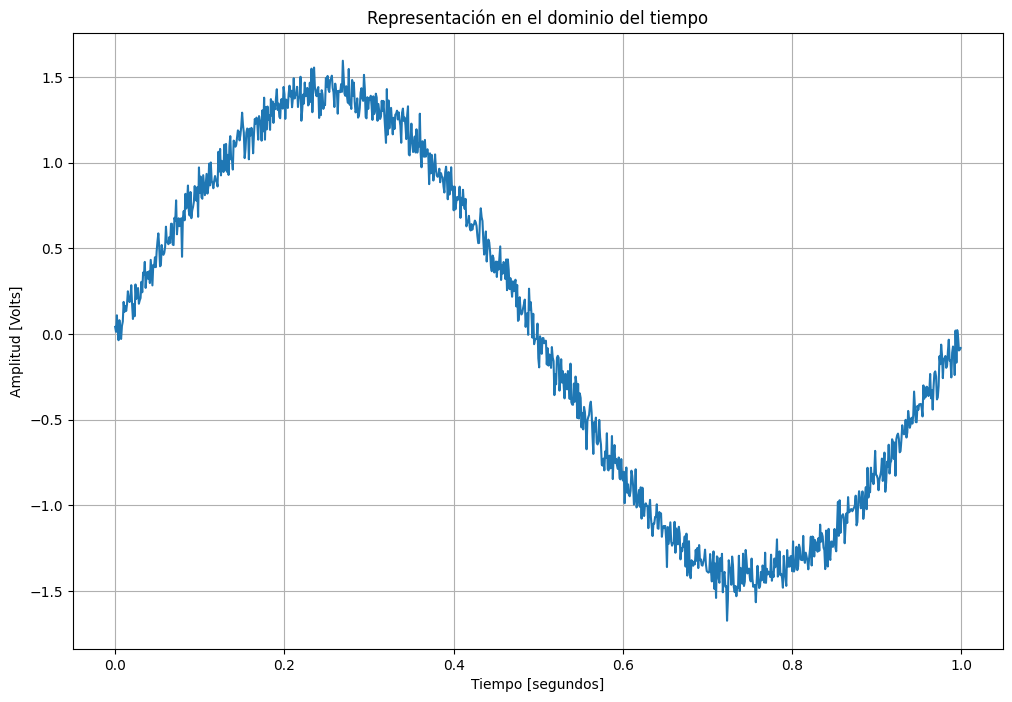

In [23]:
#Parte Temporal
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

kn = 1
pr = kn*((q**2)/12)

sigma = np.sqrt(pr) #La desviación estándar del ruido normal es la raiz de la potencia
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

plt.figure(figsize=(12, 8))
plt.plot(tt, zz)
plt.title("Representación en el dominio del tiempo")
plt.xlabel("Tiempo [segundos]")
plt.ylabel("Amplitud [Volts]")
plt.grid(True)

plt.show()

&emsp;&emsp;&emsp; Este mismo resultado se pudo ver en los trabajos anteriores, salvo que ahora tomamos la potencia del ruido en base al 
paso de cuantización (**q**). Un resultado importante a analizar que no se hizo en el trabajo anterior, es la relación señal-ruido o *SNR* de una señal, que relaciona la potencia de la señal en base a la potencia del ruido que tiene esta, en este caso obtuvimos un $SNR = 22.83 dB$, el cuál es un valor relativo en cuanto a qué utilidad le demos.

### | 4 Bits con $K_n =1$   
#### ->  Señal cuantizada y su Comportamiento en el espectro de la frecuencia 
&emsp;&emsp;&emsp; Graficamos la señal cuantizada y las señales base que la forma, la compararemos con una senoidal de la misma frecuencia "limpia". En el espectro de frecuencias se verán los 3 gráficos de las 3 respectivas señales.

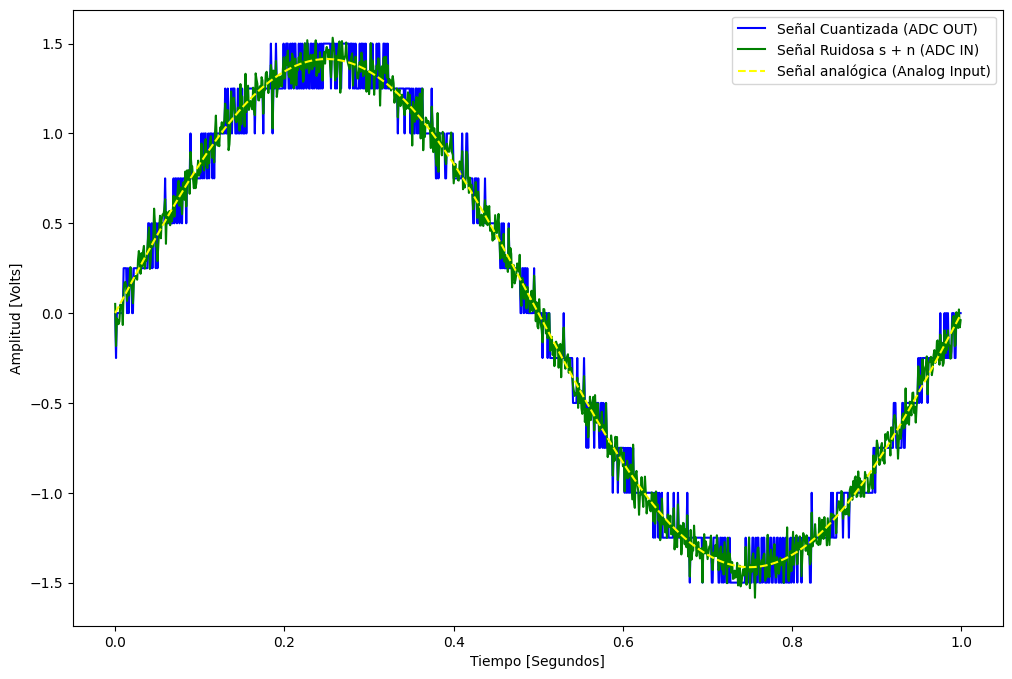

In [24]:
#Parte Temporal
vmax= np.sqrt(2*Ps)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(pr) #La desviación estándar del ruido normal es la raiz de la potencia
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

zzq, Ezzq = cuantizar(zz,vref,q)


 
plt.figure(figsize=(12, 8))
plt.plot(tt, zzq,label='Señal Cuantizada (ADC OUT)',color='blue')
plt.plot(tt, zz,label="Señal Ruidosa s + n (ADC IN)",color='green')
plt.plot(tt, xx,label="Señal analógica (Analog Input)",color='yellow',linestyle='--')
plt.legend(loc='upper right',bbox_to_anchor=(1, 1))

plt.xlabel("Tiempo [Segundos]")
plt.ylabel("Amplitud [Volts]")
plt.show()

&emsp;&emsp;&emsp; Acá vemos claramente lo que se conoce como cuantización de la señal, donde percibimos que para cada valor analógico
de la señal ruidosa, corresponde un valor determinado de amplitud para la señal cuantizada, y la diferencia entre este valor y el valor real de la señal se lo conoce como error o **Ruido de cuantización**. Vemos que para el caso de un ADC de 4 Bits  la salida que puede entregar este comparado a la señal analógica ideal (el seno perfecto) es muy distinta y cuenta con un error muy elevada para ciertos instantes, llegando a valores de hasta $0.25 Volts$ de amlitud. Además podemos decir que representa bien a la señal en cuanto al comportamiento de una función de este tipo.  

&emsp;&emsp;&emsp; Ahora pasamos a ver lo que le ocurre a la parte frecuencial de las 3 señales

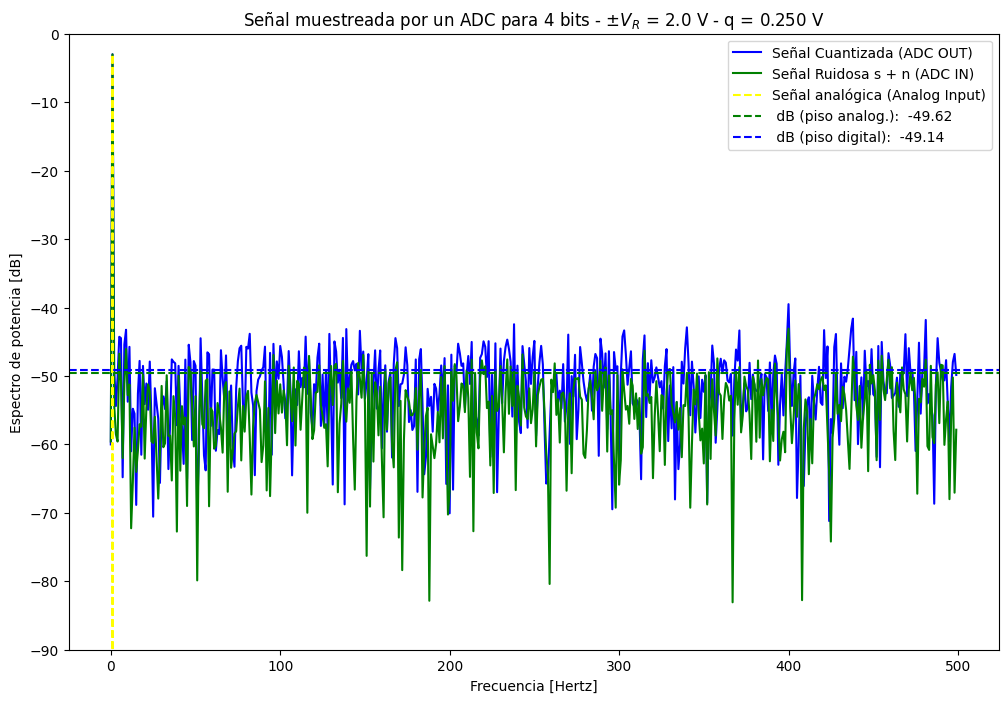

SNR experimental = 19.387170512025413 dB
SNR teórico (ADC ideal) = 25.84  dB


In [26]:
#Parte Temporal
vmax= np.sqrt(2*Ps*ff)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(pr) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

zzq, Ezzq = cuantizar(zz,vref,q)


#Parte frecuencial
fftzzq = fft(zzq)
fftzzq = fftzzq[:N//2] 
fftzzq_abs = np.abs(fftzzq)/N

fftzz = fft(zz)
fftzz = fftzz[:N//2] 
fftzz_abs = np.abs(fftzz)/N

fftxx = fft(xx)
fftxx = fftxx[:N//2] 
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


#Piso analógico
fftrr = fft(rr)
fftrr = fftrr[:N//2]
fftrr_abs = np.abs(fftrr)*2/N
piso_analog_db = np.mean(20*np.log10(fftrr_abs[1:])) #excluyo la bin de DC
 
#Piso digital 
fftEzzq = fft(Ezzq)
fftEzzq = fftEzzq[:N//2]
fftEzzq_abs = np.abs(fftEzzq)*2/N
piso_digital_db = np.mean(20*np.log10(fftEzzq_abs[1:])) #excluyo la bin de DC

PQ_teorico_rms = q/np.sqrt(12)
PQ_Exprerimental = np.mean(Ezzq**2)
difRuido = PQ_teorico_rms - PQ_Exprerimental

plt.figure(figsize=(12, 8))
plt.plot(freq, 20*np.log10(fftzzq_abs),label='Señal Cuantizada (ADC OUT)',color='blue')
plt.plot(freq, 20*np.log10(fftzz_abs),label='Señal Ruidosa s + n (ADC IN)',color='green')
plt.plot(freq, 20*np.log10(fftxx_abs),label='Señal analógica (Analog Input)',color='yellow',linestyle='--')

plt.title(f"Señal muestreada por un ADC para {B} bits - ±$V_R$ = 2.0 V - q = {q:.3f} V")
plt.axhline(piso_analog_db, color='green', linestyle='--',
            label=f' dB (piso analog.):  {piso_analog_db:.4}')
plt.axhline(piso_digital_db, color='blue', linestyle='--',
            label=f' dB (piso digital):  {piso_digital_db:.4}')

plt.legend(loc='upper right',bbox_to_anchor=(1, 1))
plt.xlabel("Frecuencia [Hertz]")
plt.ylabel("Espectro de potencia [dB]")
plt.ylim(-90, 0)

plt.show()

#Cálculo SNR Experimental

PotSeñal = 2* fftzzq_abs[k]**2

PotRuido =2*  np.sum (fftzzq_abs[2:(N//2)]**2) 

SNR_db = 10*np.log10(PotSeñal / PotRuido)

print("SNR experimental =", SNR_db, "dB")

SNR_teorico_db = 6.02*B + 1.76
print("SNR teórico (ADC ideal) =", SNR_teorico_db," dB")

&emsp;&emsp;&emsp; Se recortó el eje Y del gráfico ya que teóricamente un piso con amplitud 0 para la señal analógica representa $-∞ ´dB$. Observamos, como es evidente, que las 3 señales tienen un pico de $0 dB$ en la frecuencia característica. Aunque no se puede apreciar del todo bien
para este caso, se observa que el piso de ruido de la señal ruidosa y la cuantizada es muy similar, osea que hay un diferencia muy pequeña entre ellas, pero si vemos la energía, se nota que en las frecuencias parásitas de la señal cuantizada es mayor que la que tiene la señal que entra al ADC. Observamos la relación que hay entre los SNR calculados, donde, si bien su diferencia es de alrededor de **6dB** podemos decir que hay una consistencia entre lo teórico y lo práctico,  porque el SNR de cuantización teórico solo toma en cuenta el ruido que produce la cuantización, pero no ve el ruido analógico que acompaña a la señal. 

&emsp;&emsp;&emsp;Pasamos a ver el histograma característico para el ruido de cuantización

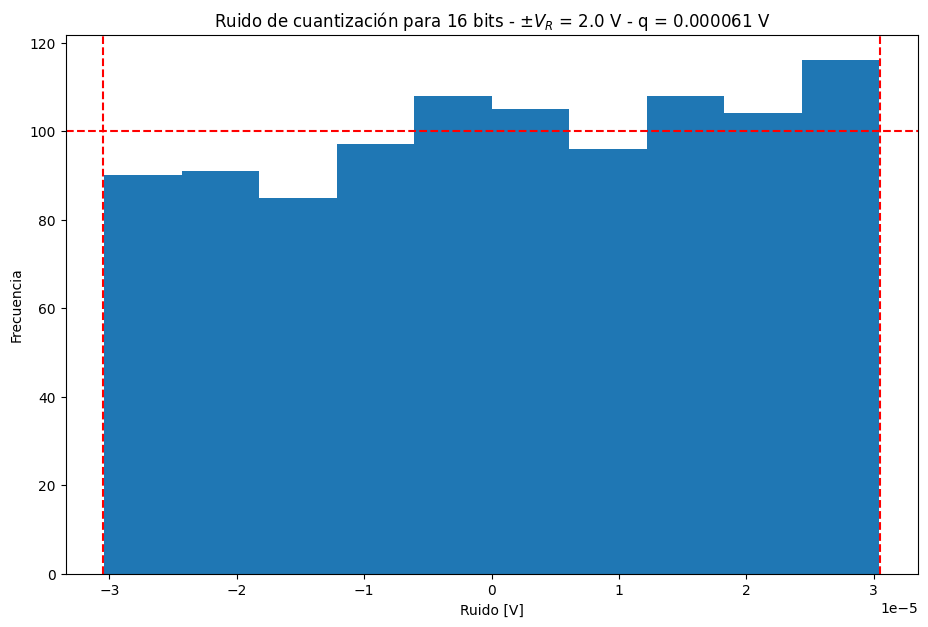

In [71]:
def Histograma(nq, qq, B):
    plt.figure(figsize=(11, 7))
    n_bins = 10
    counts, bins, _ = plt.hist(nq, bins=n_bins)
    esperado = len(nq) / n_bins  # altura teórica uniforme
    plt.axvline(-qq/2, color='red', linestyle='--')
    plt.axvline(qq/2, color='red', linestyle='--')
    plt.axhline(esperado, color='red', linestyle='--')
    plt.title(f"Ruido de cuantización para {B} bits - ±$V_R$ = 2.0 V - q = {qq:.6f} V")
    plt.xlabel("Ruido [V]")
    plt.ylabel("Frecuencia")
    #plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

Histograma(Ezzq,q,B)

&emsp;&emsp;&emsp;Tal vez acá no se pueda observar bien, pero estamos viendo una distribución de valores de acuerdo a la frecuencia o bin en el que
nos posicionemos, este gráfico nos revela estadística mediante, cómo se distribuirán los valores de mi cuantización. En este caso vemos un gráfico bastante uniforme.


### | 4 Bits con $K_n =\frac{1}{10}$   
&emsp;&emsp;&emsp; En las próximas secciones se cambiarán la cantidad de Bits del ADC y el factor $K_n$ , parámetros fundamentales para modificar tanto cómo se comporta, como el impacto que tiene el ruido en mi salida digital.

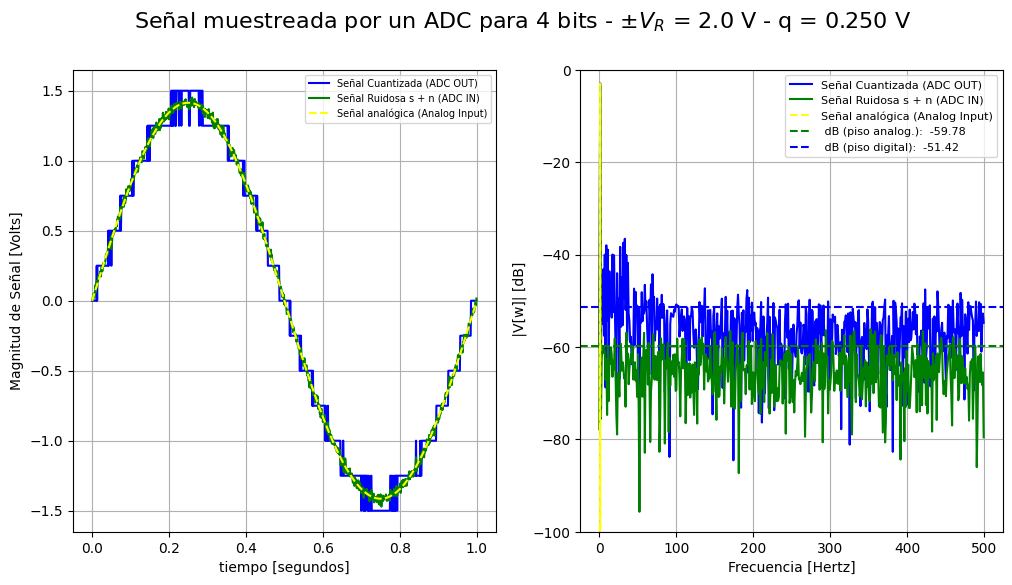

SNR experimental = 21.91281567450208 dB
SNR teórico (ADC ideal) = 25.84  dB


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
#Parte Temporal
    #Factores para cuantizar la señal
B = 4
q =(2*vref)/(2**B)
    #Factores para parametrizar el ruido
kn = 1/10
pr = kn*((q**2)/12)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(pr) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

zzq, Ezzq = cuantizar(zz,vref,q)

ax1.plot(tt, zzq,label='Señal Cuantizada (ADC OUT)',color='blue')
ax1.plot(tt, zz,label="Señal Ruidosa s + n (ADC IN)",color='green')
ax1.plot(tt, xx,label="Señal analógica (Analog Input)",color='yellow',linestyle='--')
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)
ax1.legend(fontsize=7) 

#Parte frecuencial
fftzzq = fft(zzq)
fftzzq = fftzzq[:N//2] 
fftzzq_abs = np.abs(fftzzq)/N

fftzz = fft(zz)
fftzz = fftzz[:N//2] 
fftzz_abs = np.abs(fftzz)/N

fftxx = fft(xx)
fftxx = fftxx[:N//2] 
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


#Piso analógico
fftrr = fft(rr)
fftrr = fftrr[:N//2]
fftrr_abs = np.abs(fftrr)*2/N
piso_analog_db = np.mean(20*np.log10(fftrr_abs[1:])) #excluyo la bin de DC
 
#Piso digital 
fftEzzq = fft(Ezzq)
fftEzzq = fftEzzq[:N//2]
fftEzzq_abs = np.abs(fftEzzq)*2/N
piso_digital_db = np.mean(20*np.log10(fftEzzq_abs[1:])) #excluyo la bin de DC

fig.suptitle(f"Señal muestreada por un ADC para {B} bits - ±$V_R$ = 2.0 V - q = {q:.3f} V", fontsize=16)

ax2.plot(freq, 20*np.log10(fftzzq_abs),label='Señal Cuantizada (ADC OUT)',color='blue')
ax2.plot(freq, 20*np.log10(fftzz_abs),label='Señal Ruidosa s + n (ADC IN)',color='green')
ax2.plot(freq, 20*np.log10(fftxx_abs),label='Señal analógica (Analog Input)',color='yellow',linestyle='--')

ax2.axhline(piso_analog_db, color='green', linestyle='--',
            label=f' dB (piso analog.):  {piso_analog_db:.4}')
ax2.axhline(piso_digital_db, color='blue', linestyle='--',
            label=f' dB (piso digital):  {piso_digital_db:.4}')
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel(" |V[w]| [dB]")
ax2.set_ylim(-100, 0)
ax2.grid(True)
v

plt.show()
#Cálculo SNR Experimental

PotSeñal = 2* fftzzq_abs[k]**2

PotRuido =2*  np.sum (fftzzq_abs[2:(N//2)]**2) 

SNR_db = 10*np.log10(PotSeñal / PotRuido)

print("SNR experimental =", SNR_db, "dB")

SNR_teorico_db = 6.02*B + 1.76
print("SNR teórico (ADC ideal) =", SNR_teorico_db," dB")

&emsp;&emsp;&emsp; Debido a que el factor $K_n$ es menor, y este tiene relación directa con el ruido de la señal, observamos como cláramente el ruido de la señal de entrada disminuye considerablemente, comportándose muy paraecido a la señal "ideal". Un efecto interesante que no se notaba demasiado en el ejemplo anterior, son los picos y error que se produce en las máximos y mínimos de la función. Por otro lado, en el espectro de la frecuencia, vemos que los pisos de ruido de las dos señales varía considerablemente entre sí, y ya no son comparables, notando que vemos una dispersión de energía mayor en el espectro generado por la señal digitalizada. Por otro lado, notamos que el **SNR** de la señal experimental aumenta, todavía no llega a igual o ser comparable con el medido teóricamente, pero mejora comparandolo con el ejemplo donde $k_n = 1$.

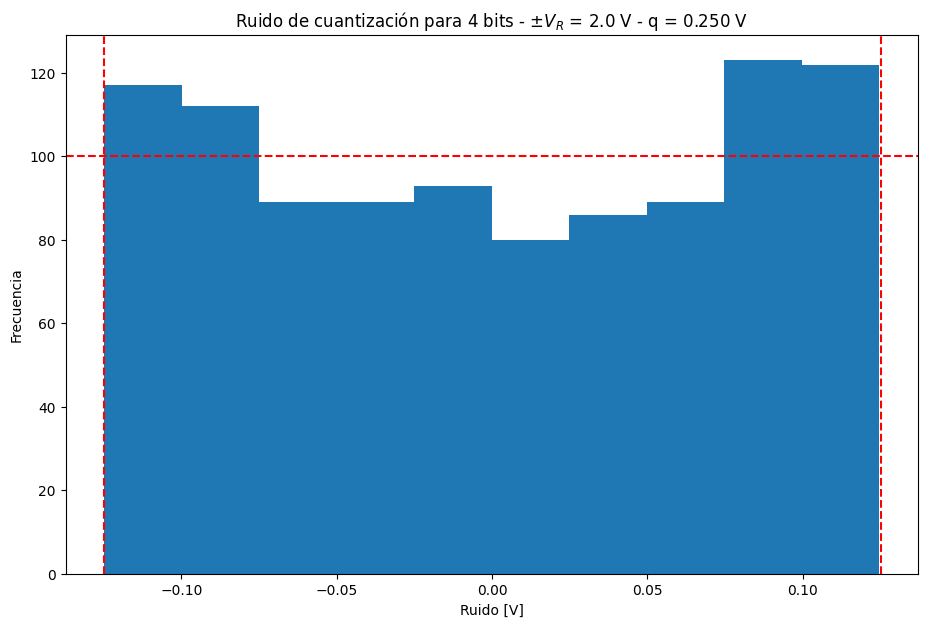

In [38]:
Histograma(Ezzq,q,B)

&emsp;&emsp;&emsp; El gráfico del error parece asemejarse más a una "U". Estos significa, si lo interpretamos como una distribución probabilística,
que es más probable que el valor que tome la cuantización sea el de los extremos del espectro, es decir de $+q/2$ y de $-q/2$, lo cual para señales
de esta índole no debería afectar, pero que probablemente ante señales desconocidas y con formas no tan habituales, observemos una pérdida de información considerable. 

### | 8 Bits con $K_n = 1 $   
&emsp;&emsp;&emsp; En las próximas secciones se cambiarán la cantidad de Bits del ADC y el factor $K_n$ , parámetros fundamentales para modificar tanto cómo se comporta, como el impacto que tiene el ruido en mi salida digital.

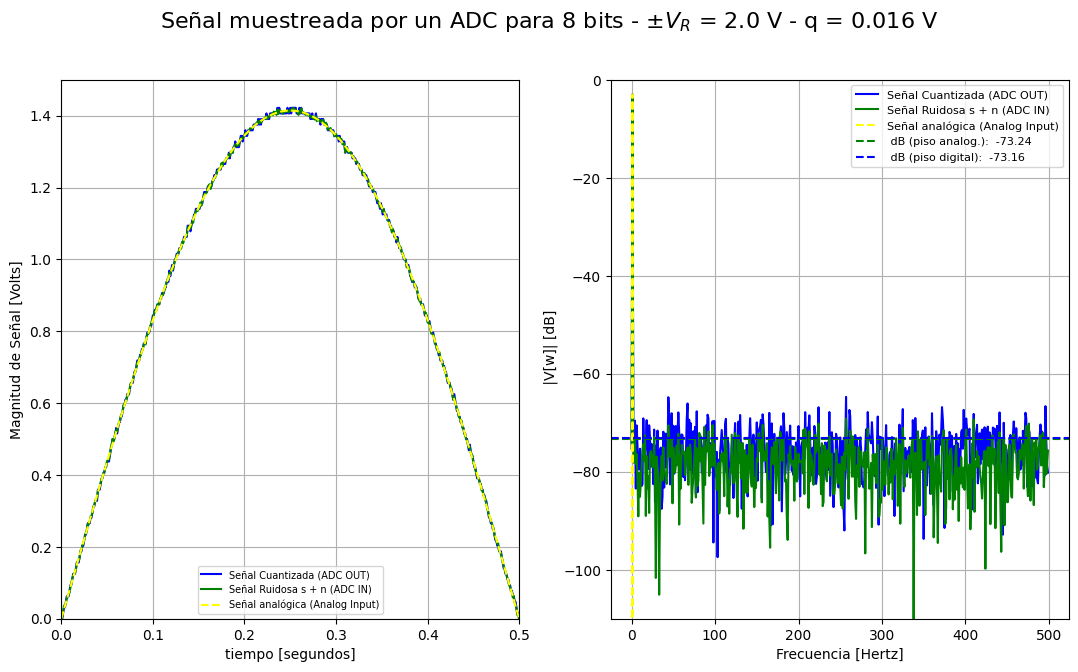

SNR experimental = 43.7518054711382 dB
SNR teórico (ADC ideal) = 49.919999999999995  dB


In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))
#Parte Temporal
    #Factores para cuantizar la señal
B = 8
q =(2*vref)/(2**B)
    #Factores para parametrizar el ruido
kn = 1
pr = kn*((q**2)/12)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(pr) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

zzq, Ezzq = cuantizar(zz,vref,q)

ax1.plot(tt, zzq,label='Señal Cuantizada (ADC OUT)',color='blue')
ax1.plot(tt, zz,label="Señal Ruidosa s + n (ADC IN)",color='green')
ax1.plot(tt, xx,label="Señal analógica (Analog Input)",color='yellow',linestyle='--')
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.set_xlim(0,0.5)
ax1.set_ylim(0,1.5)
ax1.grid(True)
ax1.legend(fontsize=7) 

#Parte frecuencial
fftzzq = fft(zzq)
fftzzq = fftzzq[:N//2] 
fftzzq_abs = np.abs(fftzzq)/N

fftzz = fft(zz)
fftzz = fftzz[:N//2] 
fftzz_abs = np.abs(fftzz)/N

fftxx = fft(xx)
fftxx = fftxx[:N//2] 
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


#Piso analógico
fftrr = fft(rr)
fftrr = fftrr[:N//2]
fftrr_abs = np.abs(fftrr)*2/N
piso_analog_db = np.mean(20*np.log10(fftrr_abs[1:])) #excluyo la bin de DC
 
#Piso digital 
fftEzzq = fft(Ezzq)
fftEzzq = fftEzzq[:N//2]
fftEzzq_abs = np.abs(fftEzzq)*2/N
piso_digital_db = np.mean(20*np.log10(fftEzzq_abs[1:])) #excluyo la bin de DC

fig.suptitle(f"Señal muestreada por un ADC para {B} bits - ±$V_R$ = 2.0 V - q = {q:.3f} V", fontsize=16)

ax2.plot(freq, 20*np.log10(fftzzq_abs),label='Señal Cuantizada (ADC OUT)',color='blue')
ax2.plot(freq, 20*np.log10(fftzz_abs),label='Señal Ruidosa s + n (ADC IN)',color='green')
ax2.plot(freq, 20*np.log10(fftxx_abs),label='Señal analógica (Analog Input)',color='yellow',linestyle='--')

ax2.axhline(piso_analog_db, color='green', linestyle='--',
            label=f' dB (piso analog.):  {piso_analog_db:.4}')
ax2.axhline(piso_digital_db, color='blue', linestyle='--',
            label=f' dB (piso digital):  {piso_digital_db:.4}')
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel(" |V[w]| [dB]")
ax2.set_ylim(-110, 0)
ax2.grid(True)
ax2.legend(fontsize=8) 

plt.show()
#Cálculo SNR Experimental

PotSeñal = 2* fftzzq_abs[k]**2

PotRuido =2*  np.sum (fftzzq_abs[2:(N//2)]**2) 

SNR_db = 10*np.log10(PotSeñal / PotRuido)

print("SNR experimental =", SNR_db, "dB")

SNR_teorico_db = 6.02*B + 1.76
print("SNR teórico (ADC ideal) =", SNR_teorico_db," dB")

&emsp;&emsp;&emsp;Se observa bien el gráfico, se recortó el gráfico para que solo se vea la mitad del período de la señal, esto desición fue tomada 
ya que así se podría observar bien los detalles de las señales del ADC, ya que si vemos el período completo a simple viste parecen ser iguales las 
3 señales. Se ve que con un $K_n = 1$ y con **8 bits** la señal pasa a tener una muy buena representación a nivel gráfico, donde el error de cuantización pasa a ser mucho menor gracias a que los niveles que puede tomar la señal son mayores, es decir hay una *mayor resolución* de esta. La señal presenta nuevamente pisos de ruido prácticamente iguales, por lo que ya podemos deducir que experimentalmente esto tiene que ver con el facto $k_n$. Lo más importante es que ahora podemos tener más fidelidad de la señal original, esto lo podemos ver en el gráfico espectral al ver la magnitud del ruido, que pasa alrededor de $-75dB$. El SNR experiental ahora es comparable con el teórico, y es un muy buen SNR.

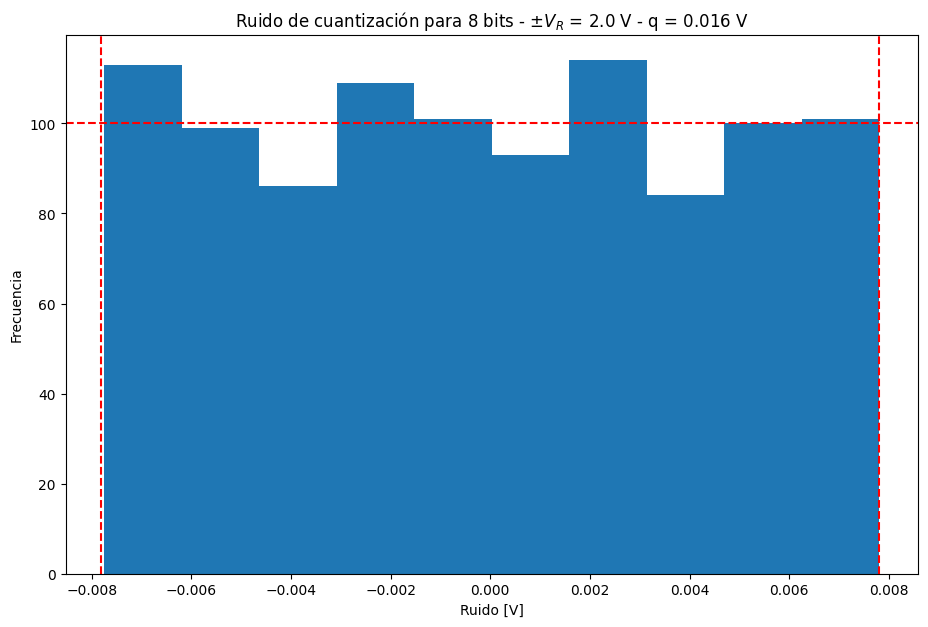

In [40]:
Histograma(Ezzq,q,B)

&emsp;&emsp;&emsp; Se vé un gráfico bastante similar a los anteriores, sobre todo al primero que vimos, aunque ahora los límites cambiaron debido
al cambio de la cantidad de bits.

### | 16 Bits con $K_n = 10 $   
&emsp;&emsp;&emsp; En las próximas secciones se cambiarán la cantidad de Bits del ADC y el factor $K_n$ , parámetros fundamentales para modificar tanto cómo se comporta, como el impacto que tiene el ruido en mi salida digital.

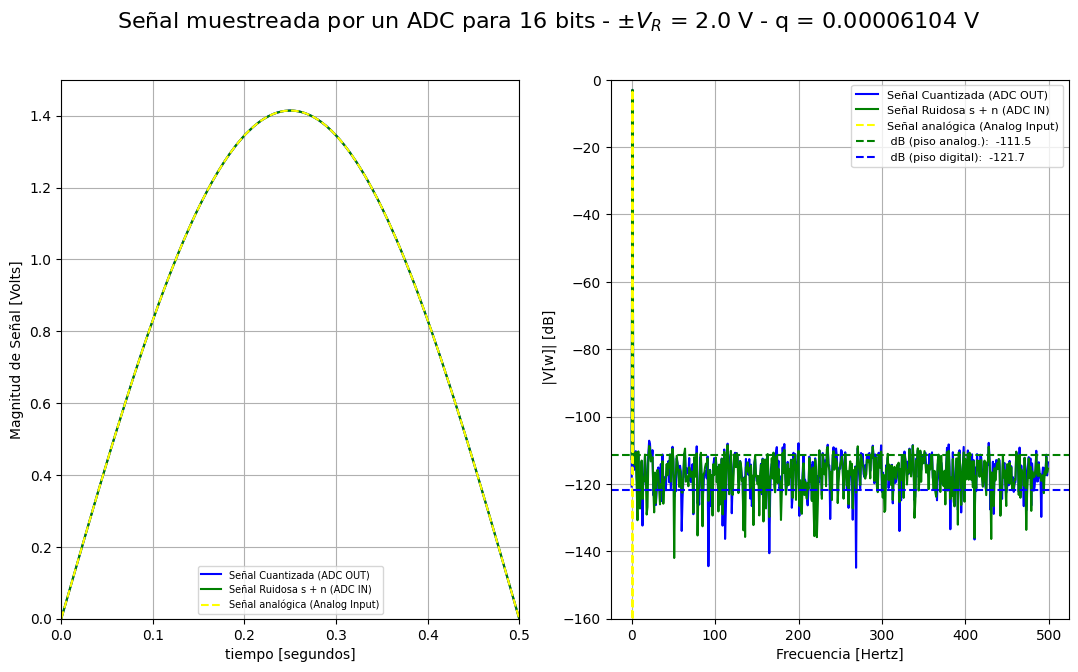

SNR experimental = 84.66656002733878 dB
SNR teórico (ADC ideal) = 98.08  dB


In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))
#Parte Temporal
    #Factores para cuantizar la señal
B = 16
q =(2*vref)/(2**B)
    #Factores para parametrizar el ruido
kn = 10
pr = kn*((q**2)/12)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(pr) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr

zzq, Ezzq = cuantizar(zz,vref,q)

ax1.plot(tt, zzq,label='Señal Cuantizada (ADC OUT)',color='blue')
ax1.plot(tt, zz,label="Señal Ruidosa s + n (ADC IN)",color='green')
ax1.plot(tt, xx,label="Señal analógica (Analog Input)",color='yellow',linestyle='--')
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.set_xlim(0,0.5)
ax1.set_ylim(0,1.5)
ax1.grid(True)
ax1.legend(fontsize=7) 

#Parte frecuencial
fftzzq = fft(zzq)
fftzzq = fftzzq[:N//2] 
fftzzq_abs = np.abs(fftzzq)/N

fftzz = fft(zz)
fftzz = fftzz[:N//2] 
fftzz_abs = np.abs(fftzz)/N

fftxx = fft(xx)
fftxx = fftxx[:N//2] 
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


#Piso analógico
fftrr = fft(rr)
fftrr = fftrr[:N//2]
fftrr_abs = np.abs(fftrr)*2/N
piso_analog_db = np.mean(20*np.log10(fftrr_abs[1:])) #excluyo la bin de DC
 
#Piso digital 
fftEzzq = fft(Ezzq)
fftEzzq = fftEzzq[:N//2]
fftEzzq_abs = np.abs(fftEzzq)*2/N
piso_digital_db = np.mean(20*np.log10(fftEzzq_abs[1:])) #excluyo la bin de DC

fig.suptitle(f"Señal muestreada por un ADC para {B} bits - ±$V_R$ = 2.0 V - q = {q:.8f} V", fontsize=16)

ax2.plot(freq, 20*np.log10(fftzzq_abs),label='Señal Cuantizada (ADC OUT)',color='blue')
ax2.plot(freq, 20*np.log10(fftzz_abs),label='Señal Ruidosa s + n (ADC IN)',color='green')
ax2.plot(freq, 20*np.log10(fftxx_abs),label='Señal analógica (Analog Input)',color='yellow',linestyle='--')

ax2.axhline(piso_analog_db, color='green', linestyle='--',
            label=f' dB (piso analog.):  {piso_analog_db:.4}')
ax2.axhline(piso_digital_db, color='blue', linestyle='--',
            label=f' dB (piso digital):  {piso_digital_db:.4}')
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel(" |V[w]| [dB]")
ax2.set_ylim(-160, 0)
ax2.grid(True)
ax2.legend(fontsize=8) 

plt.show()
#Cálculo SNR Experimental

PotSeñal = 2* fftzzq_abs[k]**2

PotRuido =2*  np.sum (fftzzq_abs[2:(N//2)]**2) 

SNR_db = 10*np.log10(PotSeñal / PotRuido)

print("SNR experimental =", SNR_db, "dB")

SNR_teorico_db = 6.02*B + 1.76
print("SNR teórico (ADC ideal) =", SNR_teorico_db," dB")

&emsp;&emsp;&emsp;Se observa bien el gráfico nuevamente, prácticamente no hay deformación de la señal. En estos últimos 2 gráficos ya vemos como un 
ADC de **16 Bits** es un gran dispositivo para representar una señal fidedignamente, incluso con un pésimo factor $k_n$. Volvemos a observvar que el piso de ruido varía entre la entrada y la salida, pero al ser tan baja la escala en dB, esto ya pasa a un segundo plano si se quiere.

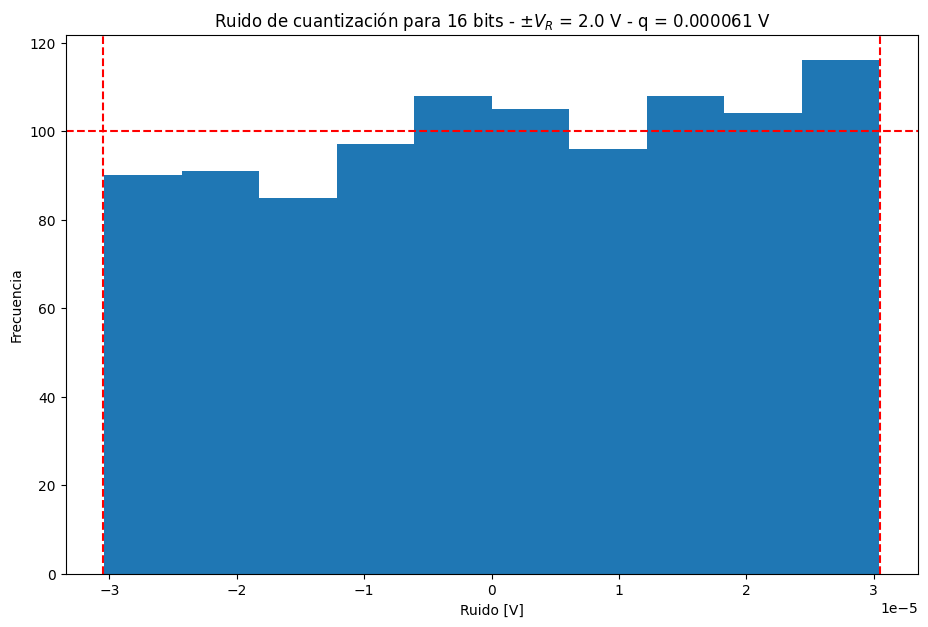

In [72]:
Histograma(Ezzq,q,B)

&emsp;&emsp;&emsp; Observamos un corrimiento leve hacia el extremo superior, pero al estar observando valores tan bajos, esto es más anecdótico a menos que necesitamos una *"presición quirúrjica"*. 

## | Gráfico comparativo de SNR

| Cantidad de Bits y factor $k_n$ | SNR experimental (dB) | SNR teórico (dB) | Diferencia (dB) |
|:---:|---:|---:|---:|
| 4 Bits ° 1 | 19.39 | 25.84 | 6.45 |
| 4 Bits ° 1/10 | 21.91 | 25.84 | 3.93 |
| 8 Bits ° 1 | 43.75 | 49.92 | 6.17 |
| 16 Bits ° 10 | 84.67 | 98.08 | 13.41 |

&emsp;&emsp;&emsp;Al comparar los valores obtenidos experimentalmente con los valores teóricos correspondientes a un ADC ideal, se observa que el SNR experimental es inferior al teórico en todos los casos. Esta diferencia puede atribuirse a factores no contemplados en el modelo ideal, como la presencia de ruido analógico, errores de cuantización, entre otros factores no contemplados. En particular, para el cuarto caso se observa una diferencia más significativa entre ambos valores, lo que se lo atribuimos al factor $k_n$, factor el cual lo tomamos para contemplar de alguna forma (de forma numérica) estos factores no contemplados.

## | Conclusiones

&emsp;&emsp;&emsp; Por último, podemos decir que la diferencia entre los $SNR$ de cada ADC es debido al factor $k_n$, y esto impacta directamente con el comportamiento que toma el dispositivo *ADC* y la señal de salida por consecuencia. Pudimos observar que al aumentar la cantidad de Bits el ruido disminuye drásticamente con tan solo unos cuantos Bits y la fidelidad de la señal es mucho mayor. Además vimos que en los picos de la señal sinusoidal, el *ADC* sufre y genera picos de nivel de cuantización que deforman esas secciones de la señal. Además los gráficos del ruido de cuantización nos sirvieron para poder analizar la distribución del ruido en cada uno de los casos, siendo en su mayoría iguales salvo en el de 4 Bits que vimos una supuesta distribución en "U".